# Anomaly Detection: Network Flow Classification with ML 
### Comprehensive ML Pipeline for DNS Tunneling & Network Behavior Detection

This notebook implements a production-grade ML pipeline for detecting anomalous network flows.

In [1]:
# Import Required Libraries
import os
import sys
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve,
                             f1_score, precision_score, recall_score, auc, precision_recall_curve)
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import scipy.stats as stats

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Section 2: Load Preprocessed Data

In [2]:
# Set data path (notebook is in notebooks/ subdirectory, data is in parent data/ directory)
data_dir = Path("../data")

# Load preprocessed datasets (already split and scaled)
train_data = pd.read_csv(data_dir / "train_data.csv")
test_data = pd.read_csv(data_dir / "test_data.csv")

# Load feature names
with open(data_dir / "feature_names.txt", 'r') as f:
    feature_names = [line.strip() for line in f.readlines()]

print("=" * 70)
print("DATASET LOADING SUMMARY")
print("=" * 70)
print(f"\n✓ Training set shape: {train_data.shape}")
print(f"✓ Test set shape: {test_data.shape}")
print(f"✓ Feature count: {len(feature_names)}")
print(f"\nFeature names: {feature_names}")

# Prepare X and y (separate features and labels)
X_train = train_data[feature_names].values
y_train = train_data['Label'].values

X_test = test_data[feature_names].values
y_test = test_data['Label'].values

print(f"\n✓ Training features shape: {X_train.shape}, Labels shape: {y_train.shape}")
print(f"✓ Test features shape: {X_test.shape}, Labels shape: {y_test.shape}")

DATASET LOADING SUMMARY

✓ Training set shape: (290296, 32)
✓ Test set shape: (86159, 32)
✓ Feature count: 31

Feature names: ['Character_frequency_entropy', 'Domain_name_length', 'Non_printable_character_count', 'Digit_letter_ratio', 'Unique_subdomains_per_flow', 'NXDomain_ratio', 'Query_rate_per_sec', 'Response_size_variance', 'Duration', 'FlowBytesSent', 'FlowSentRate', 'FlowBytesReceived', 'FlowReceivedRate', 'PacketLengthVariance', 'PacketLengthStandardDeviation', 'PacketLengthMean', 'PacketLengthMedian', 'PacketLengthMode', 'PacketLengthSkewFromMedian', 'PacketLengthSkewFromMode', 'PacketLengthCoefficientofVariation', 'PacketTimeStandardDeviation', 'PacketTimeMedian', 'PacketTimeSkewFromMedian', 'PacketTimeSkewFromMode', 'PacketTimeCoefficientofVariation', 'ResponseTimeTimeStandardDeviation', 'ResponseTimeTimeMean', 'ResponseTimeTimeMedian', 'ResponseTimeTimeSkewFromMedian', 'ResponseTimeTimeSkewFromMode']

✓ Training features shape: (290296, 31), Labels shape: (290296,)
✓ Test f

## Section 3: Train Anomaly Detection Models

In [3]:
# 4. Random Forest (Supervised - on sample)
models = {}
print("\n4. Training Random Forest (Supervised)...")

rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
models['Random Forest']=rf



4. Training Random Forest (Supervised)...


In [4]:
# 5. Gradient Boosting (Supervised - on sample)
print("\n5. Training Gradient Boosting Classifier...")

gb = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )
gb.fit(X_train, y_train)
models['Gradient Boosting']= gb



5. Training Gradient Boosting Classifier...


## Section 4: Model Evaluation and Comparison

In [5]:
# Evaluate models on test set
print("\n" + "=" * 70)
print("MODEL EVALUATION AND COMPARISON (TEST SET - Held-Out Data)")
print("=" * 70)

evaluation_results = {}

for model_name, model in models.items():
    print(f"\n{'='*70}")
    print(f"Model: {model_name}")
    print(f"{'='*70}")

    y_pred = None
    y_pred_proba = None

    if model_name == 'Autoencoder':
        # Reconstruction error on validation set to find threshold (no leakage)
        X_val_reconstructed = model.predict(X_val, verbose=0)
        val_errors = np.mean(np.square(X_val - X_val_reconstructed), axis=1)
        threshold = np.percentile(val_errors, 75)

        # Apply threshold to test set
        X_test_reconstructed = model.predict(X_test, verbose=0)
        reconstruction_errors = np.mean(np.square(X_test - X_test_reconstructed), axis=1)
        y_pred = (reconstruction_errors > threshold).astype(int)

        # Normalize errors to [0,1] range for probability proxy
        err_min, err_max = reconstruction_errors.min(), reconstruction_errors.max()
        y_pred_proba = (reconstruction_errors - err_min) / (err_max - err_min + 1e-9)

    elif hasattr(model, 'predict_proba'):
        # Supervised models (RF, GradientBoosting, etc.)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    elif hasattr(model, 'score_samples'):
        # Anomaly models: score_samples returns negative scores
        # More negative = more anomalous, so flip the sign before sigmoid
        anomaly_scores = model.score_samples(X_test)
        y_pred_proba = 1 / (1 + np.exp(anomaly_scores))  # flipped: high prob = anomalous

        # predict() returns -1 (anomaly) or 1 (normal) — convert to 0/1
        raw_pred = model.predict(X_test)
        y_pred = np.where(raw_pred == -1, 1, 0)  # -1 → malicious (1), 1 → benign (0)

    else:
        print(f"  [SKIP] No supported prediction method for {model_name}")
        continue

    # Calculate metrics
    accuracy  = (y_pred == y_test).mean()
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)

    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba)
    except Exception as e:
        print(f"  [WARN] ROC-AUC could not be computed: {e}")
        roc_auc = np.nan

    # Store results
    evaluation_results[model_name] = {
        'accuracy':      accuracy,
        'precision':     precision,
        'recall':        recall,
        'f1':            f1,
        'roc_auc':       roc_auc,
        'predictions':   y_pred,
        'probabilities': y_pred_proba
    }

    # Print metrics
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}" if not np.isnan(roc_auc) else "  ROC-AUC:   N/A")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n  Confusion Matrix:")
    print(f"    TN: {cm[0,0]:6d}  FP: {cm[0,1]:6d}")
    print(f"    FN: {cm[1,0]:6d}  TP: {cm[1,1]:6d}")

    # Classification report
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=['Benign', 'Malicious'], digits=4))

# Summary comparison table
print(f"\n{'='*70}")
print("SUMMARY COMPARISON TABLE")
print(f"{'='*70}")

comparison_df = pd.DataFrame({
    k: {m: v for m, v in vals.items() if m in ['accuracy','precision','recall','f1','roc_auc']}
    for k, vals in evaluation_results.items()
}).T.sort_values('f1', ascending=False)

print("\nMetrics (sorted by F1-Score):")
print(comparison_df.to_string(float_format="{:.4f}".format))

print(f"\n✓ Model evaluation completed")


MODEL EVALUATION AND COMPARISON (TEST SET - Held-Out Data)

Model: Random Forest
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    0.9999
  F1-Score:  0.9999
  ROC-AUC:   1.0000

  Confusion Matrix:
    TN:  62206  FP:      1
    FN:      2  TP:  23950

  Classification Report:
              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000     62207
   Malicious     1.0000    0.9999    0.9999     23952

    accuracy                         1.0000     86159
   macro avg     1.0000    1.0000    1.0000     86159
weighted avg     1.0000    1.0000    1.0000     86159


Model: Gradient Boosting
  Accuracy:  0.9999
  Precision: 0.9999
  Recall:    0.9999
  F1-Score:  0.9999
  ROC-AUC:   1.0000

  Confusion Matrix:
    TN:  62205  FP:      2
    FN:      3  TP:  23949

  Classification Report:
              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000     62207
   Malicious     0.9999    0.9999    0.9999     23952


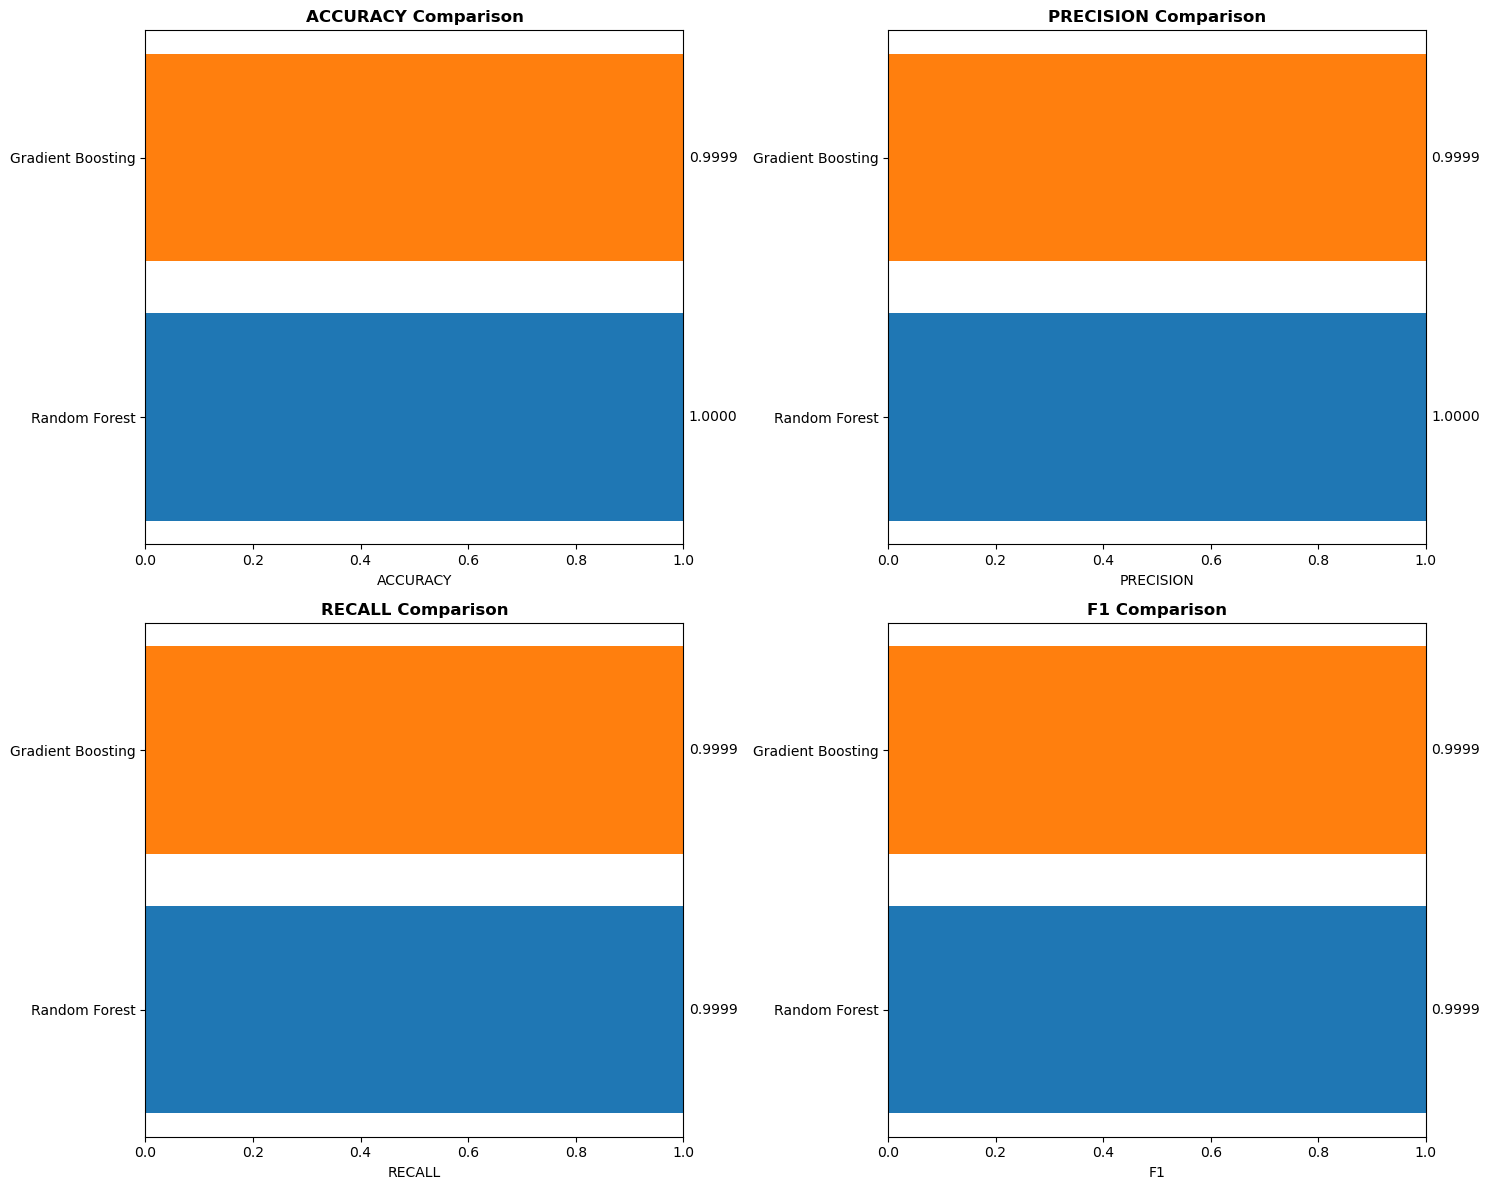

✓ Model comparison visualization saved as 'model_comparison.png'


In [6]:
# Visualize model performance comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

metrics = ['accuracy', 'precision', 'recall', 'f1']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    data = comparison_df[metric].sort_values(ascending=False)
    bars = ax.barh(range(len(data)), data.values, color=colors[:len(data)])
    
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index)
    ax.set_xlabel(metric.upper())
    ax.set_title(f'{metric.upper()} Comparison', fontsize=12, fontweight='bold')
    ax.set_xlim([0, 1])
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, data.values)):
        ax.text(val + 0.01, i, f'{val:.4f}', va='center')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Model comparison visualization saved as 'model_comparison.png'")

In [7]:
# Evaluate models on TRAINING set for comparison
print("\n" + "=" * 70)
print("MODEL EVALUATION ON TRAINING SET (For Overfitting Analysis)")
print("=" * 70)

train_results = {}

for model_name, model in models.items():
    print(f"\nEvaluating {model_name} on training set...")
    
    # Get predictions based on model type
    if model_name == 'Autoencoder':
        X_train_reconstructed = model.predict(X_train, verbose=0)
        reconstruction_errors = np.mean(np.square(X_train - X_train_reconstructed), axis=1)
        threshold = np.percentile(reconstruction_errors, 75)
        y_pred_train = (reconstruction_errors > threshold).astype(int)
        y_pred_proba_train = 1 / (1 + np.exp(-reconstruction_errors))
        
    elif hasattr(model, 'predict_proba'):
        y_pred_train = model.predict(X_train)
        y_pred_proba_train = model.predict_proba(X_train)[:, 1]
        
    elif hasattr(model, 'score_samples'):
        anomaly_scores = model.score_samples(X_train)
        y_pred_proba_train = 1 / (1 + np.exp(-anomaly_scores))
        y_pred_train = (y_pred_proba_train > 0.5).astype(int)
    
    # Calculate metrics on training set
    train_accuracy = (y_pred_train == y_train).mean()
    train_precision = precision_score(y_train, y_pred_train, zero_division=0)
    train_recall = recall_score(y_train, y_pred_train, zero_division=0)
    train_f1 = f1_score(y_train, y_pred_train, zero_division=0)
    
    try:
        train_roc_auc = roc_auc_score(y_train, y_pred_proba_train)
    except:
        train_roc_auc = np.nan
    
    train_results[model_name] = {
        'accuracy': train_accuracy,
        'precision': train_precision,
        'recall': train_recall,
        'f1': train_f1,
        'roc_auc': train_roc_auc
    }
    
    print(f"  ✓ Accuracy: {train_accuracy:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")

print(f"\n✓ Training set evaluation completed")



MODEL EVALUATION ON TRAINING SET (For Overfitting Analysis)

Evaluating Random Forest on training set...
  ✓ Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000

Evaluating Gradient Boosting on training set...
  ✓ Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000

✓ Training set evaluation completed



TRAIN vs TEST PERFORMANCE COMPARISON

Detailed Comparison:
            Model  Train Accuracy  Test Accuracy  Accuracy Gap  Train F1  Test F1   F1 Gap
    Random Forest        0.999986       0.999965      0.000021  0.999986 0.999937 0.000049
Gradient Boosting        1.000000       0.999942      0.000058  1.000000 0.999896 0.000104


Interpretation:
- Accuracy Gap & F1 Gap: Positive values suggest overfitting (model performs better on training data)
- Negative values suggest underfitting (model generalizes better)
- Small gaps (<5%) indicate good generalization


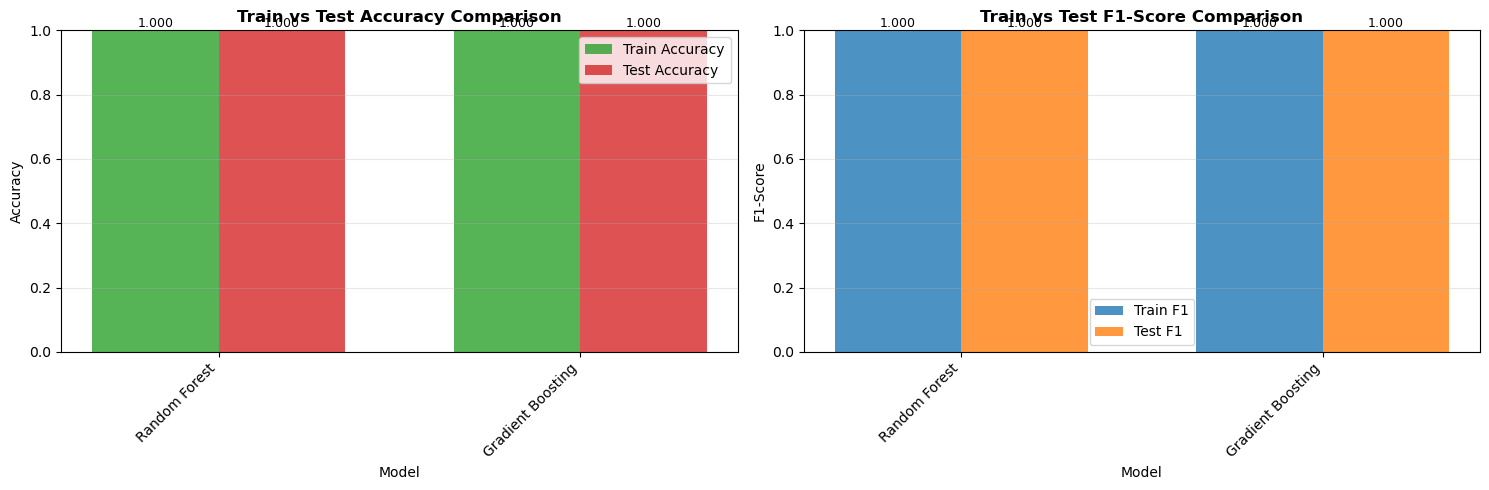


✓ Train vs Test comparison visualization saved as 'train_vs_test_comparison.png'


In [8]:
# Compare Train vs Test Performance
print("\n" + "=" * 70)
print("TRAIN vs TEST PERFORMANCE COMPARISON")
print("=" * 70)

# Create comparison DataFrame
comparison_data = []

# FIX 1: Iterate over the keys directly to get just the string names
for model_name in models: 
    if model_name in train_results and model_name in evaluation_results:
        comparison_data.append({
            'Model': model_name,
            'Train Accuracy': train_results[model_name]['accuracy'],
            'Test Accuracy': evaluation_results[model_name]['accuracy'],
            'Accuracy Gap': train_results[model_name]['accuracy'] - evaluation_results[model_name]['accuracy'],
            'Train F1': train_results[model_name]['f1'],
            'Test F1': evaluation_results[model_name]['f1'],
            'F1 Gap': train_results[model_name]['f1'] - evaluation_results[model_name]['f1']
        })

train_test_comparison = pd.DataFrame(comparison_data)

print("\nDetailed Comparison:")
print(train_test_comparison.to_string(index=False))

print("\n\nInterpretation:")
print("- Accuracy Gap & F1 Gap: Positive values suggest overfitting (model performs better on training data)")
print("- Negative values suggest underfitting (model generalizes better)")
print("- Small gaps (<5%) indicate good generalization")

# Visualize Train vs Test Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# FIX 2: Uncommented this line so the variable exists for the plots!
models_list = train_test_comparison['Model'].values
train_acc = train_test_comparison['Train Accuracy'].values
test_acc = train_test_comparison['Test Accuracy'].values

x = np.arange(len(models_list))
width = 0.35

# Accuracy comparison
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, train_acc, width, label='Train Accuracy', color='#2ca02c', alpha=0.8)
bars2 = ax1.bar(x + width/2, test_acc, width, label='Test Accuracy', color='#d62728', alpha=0.8)

ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy')
ax1.set_title('Train vs Test Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models_list, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# F1-Score comparison
ax2 = axes[1]
train_f1 = train_test_comparison['Train F1'].values
test_f1 = train_test_comparison['Test F1'].values

bars3 = ax2.bar(x - width/2, train_f1, width, label='Train F1', color='#1f77b4', alpha=0.8)
bars4 = ax2.bar(x + width/2, test_f1, width, label='Test F1', color='#ff7f0e', alpha=0.8)

ax2.set_xlabel('Model')
ax2.set_ylabel('F1-Score')
ax2.set_title('Train vs Test F1-Score Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models_list, rotation=45, ha='right')
ax2.legend()
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('train_vs_test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Train vs Test comparison visualization saved as 'train_vs_test_comparison.png'")

In [9]:
# Ensure the directory exists
models_dir = Path('trained_models')
models_dir.mkdir(exist_ok=True)
# Define the file path
model_path = models_dir / 'random_forest_model.pkl'
# Save the model (rf) to disk
with open(model_path, 'wb') as f:
    pickle.dump(rf, f)
print(f"✓ Random Forest model successfully saved to: {model_path}")

✓ Random Forest model successfully saved to: trained_models\random_forest_model.pkl
